# T3 — Paso 3: Evaluación final en los sismos de prueba

**Grupo 01** — Aplicaciones de IA en Estructuras, UPC

Este notebook responde la pregunta central del trabajo: **¿los modelos de Machine Learning
predicen la PGA mejor que la línea base tipo GMPE, respetando la física del problema?**

Criterio de éxito definido en el T2 (sección 6): un modelo supera a la línea base solo si
cumple **dos condiciones a la vez**:

1. Menor RMSE sobre ln(PGA) en los 81 sismos de prueba.
2. Curvas de atenuación físicamente coherentes: la PGA disminuye con la distancia y aumenta
   con la magnitud.

**Reglas:**

- Cada modelo se entrena con los 322 sismos de entrenamiento, usando los hiperparámetros
  guardados en el paso 2 (`results/mejores_hiperparametros.json`). Aquí **no se ajusta nada**.
- Los 81 sismos de prueba se usan por primera y única vez en este notebook.

In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.datos import preparar_datos
from src.ajuste import modelos_ajustados, cargar
from src.evaluacion import (evaluar, region_critica, curvas_atenuacion,
                            verificar_monotonia, residuos)

sns.set_theme(style="whitegrid")
np.random.seed(config.SEED)

# Colores fijos por modelo para todas las figuras
COLORES = {
    "Línea base (GMPE)": "#7f7f7f",
    "Random Forest": "#2ca02c",
    "XGBoost": "#1f77b4",
    "XGBoost monótono": "#d62728",
    "Red neuronal": "#ff7f0e",
}

## 1. Datos y modelos

In [2]:
train, test = preparar_datos()
print(f"Entrenamiento: {len(train):,} registros, {train['EQID'].nunique()} sismos")
print(f"Prueba       : {len(test):,} registros, {test['EQID'].nunique()} sismos")

print("\nHiperparámetros usados (del paso 2):")
for nombre, p in cargar().items():
    print(f"  {nombre}: {p}")

Entrenamiento: 9,976 registros, 322 sismos
Prueba       : 2,406 registros, 81 sismos

Hiperparámetros usados (del paso 2):
  Random Forest: {'n_estimators': 600, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}
  XGBoost: {'colsample_bytree': 0.718509402281633, 'learning_rate': 0.016406549192101497, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 720, 'reg_lambda': 3.5033984911586877, 'subsample': 0.679486272613669}
  XGBoost monótono: {'colsample_bytree': 0.7888859700647797, 'learning_rate': 0.014308552498147852, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 968, 'reg_lambda': 2.776253009443833, 'subsample': 0.6943939678995823}
  Red neuronal: {'alpha': 0.08568869785189001, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.0001238513729886094}


## 2. Precisión en los sismos de prueba

Cada modelo se entrena una vez y se evalúa en la prueba. La última columna mide el error
en la **región crítica para diseño** (Mw ≥ 6.5 y Rrup ≤ 20 km).

In [3]:
tabla, entrenados = evaluar(modelos_ajustados(), train, test)

base = tabla.loc["Línea base (GMPE)", "RMSE"]
tabla["mejora vs base (%)"] = 100 * (base - tabla["RMSE"]) / base

tabla.round(3)

,RMSE,MAE,R2,RMSE región crítica,mejora vs base (%)
modelo,,,,,
Línea base (GMPE),0.865,0.685,0.857,0.916,0.000
Random Forest,0.821,0.653,0.871,0.640,5.087
XGBoost,0.813,0.643,0.874,0.529,6.020
XGBoost monótono,0.818,0.651,0.872,0.458,5.503
Red neuronal,0.813,0.655,0.874,0.522,6.046


In [4]:
critica = region_critica(test)
print(f"Región crítica en la prueba: {critica.sum()} registros de "
      f"{test.loc[critica, 'EQID'].nunique()} sismos")
print("ATENCIÓN: muestra pequeña. Las cifras de esa columna son indicativas, no concluyentes.")

Región crítica en la prueba: 84 registros de 11 sismos
ATENCIÓN: muestra pequeña. Las cifras de esa columna son indicativas, no concluyentes.


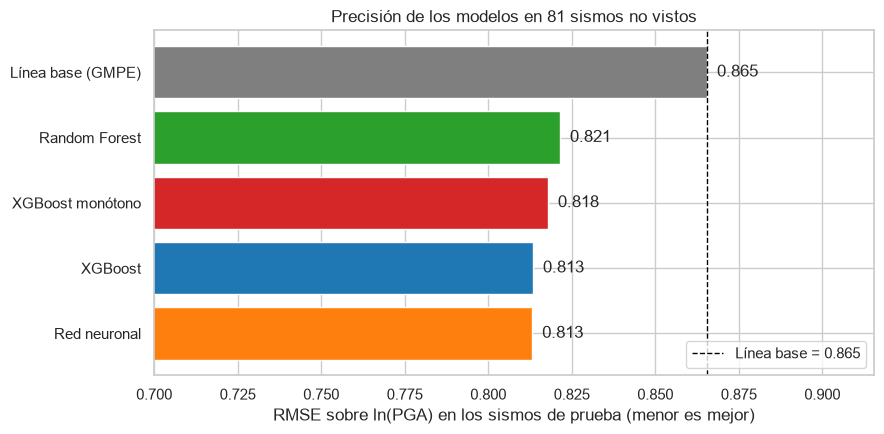

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
orden = tabla.sort_values("RMSE").index
ax.barh(orden, tabla.loc[orden, "RMSE"], color=[COLORES[m] for m in orden])
ax.axvline(base, color="black", ls="--", lw=1, label=f"Línea base = {base:.3f}")
for i, m in enumerate(orden):
    ax.text(tabla.loc[m, "RMSE"] + 0.003, i, f"{tabla.loc[m, 'RMSE']:.3f}", va="center")
ax.set_xlim(0.7, max(tabla["RMSE"]) + 0.05)
ax.set_xlabel("RMSE sobre ln(PGA) en los sismos de prueba (menor es mejor)")
ax.set_title("Precisión de los modelos en 81 sismos no vistos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../results/rmse_prueba.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. ¿La mejora es real o es azar?

Las diferencias entre modelos son de pocas centésimas. Para saber si son confiables se usa
un **bootstrap por sismo**: se remuestrean los 81 sismos de prueba 1,000 veces (con
reemplazo, conservando juntos los registros de cada sismo) y en cada repetición se calcula
cuánto mejora cada modelo el RMSE de la línea base.

Si el intervalo de confianza del 95 % de la mejora **no incluye el cero**, la mejora es
estadísticamente robusta. Si lo incluye, no se puede afirmar que el modelo sea mejor.

In [6]:
X_te = test[config.VARIABLES_ML]
y_te = test[config.OBJETIVO].values
predicciones = {m: mod.predict(X_te) for m, mod in entrenados.items()}

sismos = test["EQID"].values
ids = np.unique(sismos)
indices = {s: np.where(sismos == s)[0] for s in ids}

rng = np.random.default_rng(config.SEED)
N_BOOT = 1000
mejoras = {m: [] for m in predicciones if m != "Línea base (GMPE)"}

for _ in range(N_BOOT):
    muestra = rng.choice(ids, size=len(ids), replace=True)
    idx = np.concatenate([indices[s] for s in muestra])
    rmse_base = np.sqrt(np.mean((y_te[idx] - predicciones["Línea base (GMPE)"][idx]) ** 2))
    for m in mejoras:
        rmse_m = np.sqrt(np.mean((y_te[idx] - predicciones[m][idx]) ** 2))
        mejoras[m].append(rmse_base - rmse_m)

ic = pd.DataFrame({
    m: {"mejora media": np.mean(v),
        "IC 95% inferior": np.percentile(v, 2.5),
        "IC 95% superior": np.percentile(v, 97.5),
        "% de repeticiones en que mejora": 100 * np.mean(np.array(v) > 0)}
    for m, v in mejoras.items()
}).T
ic["¿mejora robusta?"] = np.where(ic["IC 95% inferior"] > 0, "Sí", "No")
ic.round(3)

,mejora media,IC 95% inferior,IC 95% superior,% de repeticiones en que mejora,¿mejora robusta?
Random Forest,0.050,-0.088,0.178,76.0,No
XGBoost,0.057,-0.049,0.166,84.2,No
XGBoost monótono,0.052,-0.063,0.158,80.8,No
Red neuronal,0.054,-0.054,0.151,83.5,No


## 4. Coherencia física

### 4.1 Verificación numérica de monotonía

Para cada modelo se generan predicciones en una grilla de magnitudes (4.0 a 8.0) y
distancias (1 a 200 km), en un sitio de referencia (Vs30 = 760 m/s, profundidad 10 km,
mecanismo 0). Se cuenta el porcentaje de tramos donde:

- la PGA **aumenta** al alejarse de la falla (físicamente incorrecto);
- la PGA **disminuye** al aumentar la magnitud (físicamente incorrecto).

Lo ideal es 0 % en ambos.

In [7]:
fisica = pd.DataFrame({m: verificar_monotonia(mod) for m, mod in entrenados.items()}).T
fisica.round(1)

,% violaciones en distancia,% violaciones en magnitud
Línea base (GMPE),0.0,0.0
Random Forest,15.4,13.8
XGBoost,0.0,16.2
XGBoost monótono,0.0,0.0
Red neuronal,0.0,12.4


### 4.2 Curvas de atenuación

Las curvas predichas por cada modelo para Mw 5, 6 y 7, sobre los registros reales de esas
magnitudes (puntos grises). Una curva coherente baja de forma suave y continua con la
distancia; los escalones o repuntes indican que el modelo aprendió ruido de los datos.

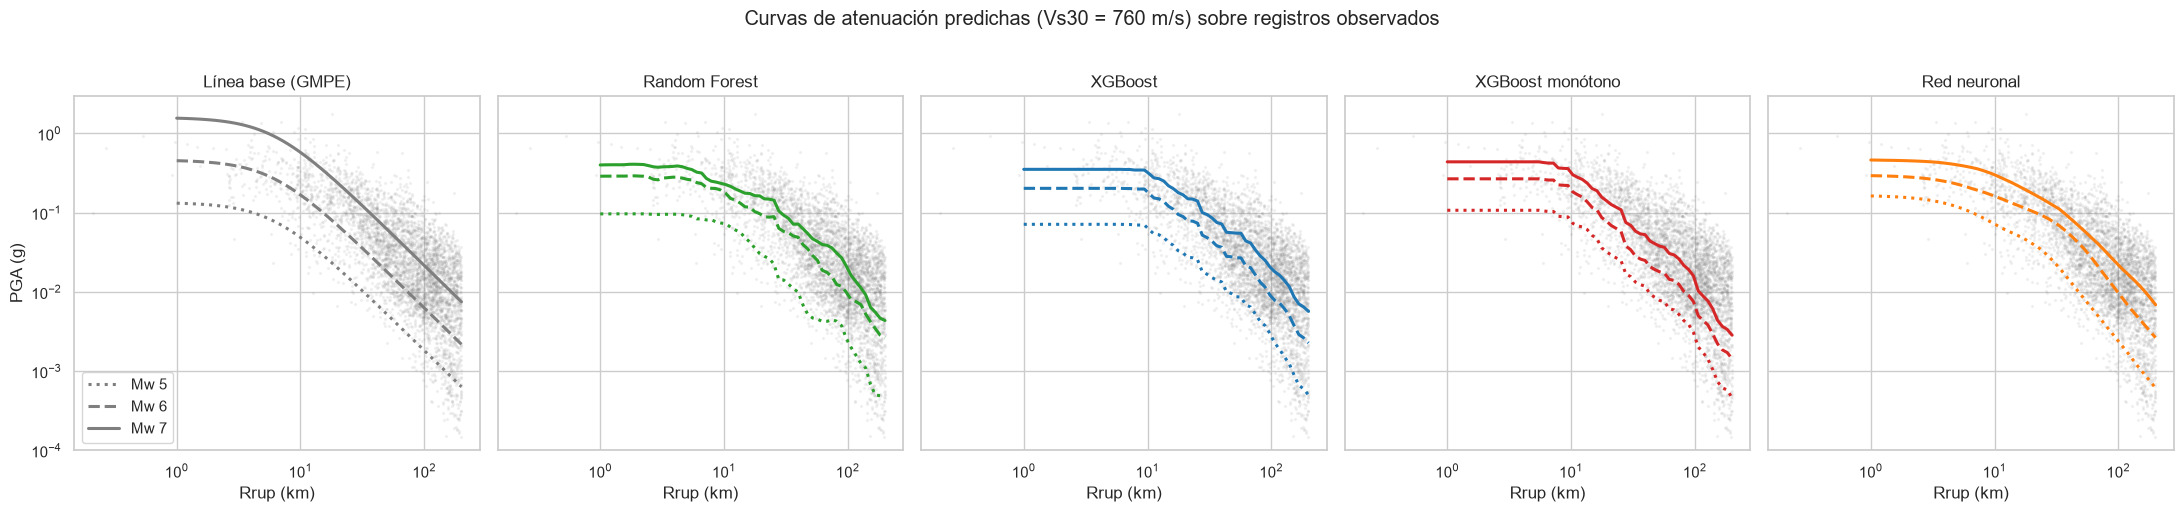

In [8]:
modelos_orden = list(entrenados)
fig, axes = plt.subplots(1, len(modelos_orden), figsize=(22, 5), sharey=True)
estilos = {5.0: ":", 6.0: "--", 7.0: "-"}

todos = pd.concat([train, test])
for ax, nombre in zip(axes, modelos_orden):
    for mw in (5.0, 6.0, 7.0):
        obs = todos[(todos["Mw"] >= mw - 0.25) & (todos["Mw"] < mw + 0.25)]
        ax.scatter(obs[config.DISTANCIA], obs["PGA"], s=2, alpha=0.08, color="gray")
    curvas = curvas_atenuacion(entrenados[nombre])
    for mw in curvas.columns:
        ax.plot(curvas.index, curvas[mw], estilos[mw], color=COLORES[nombre],
                lw=2.2, label=f"Mw {mw:.0f}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylim(1e-4, 3)
    ax.set_title(nombre)
    ax.set_xlabel("Rrup (km)")
axes[0].set_ylabel("PGA (g)")
axes[0].legend(loc="lower left")
fig.suptitle("Curvas de atenuación predichas (Vs30 = 760 m/s) sobre registros observados", y=1.02)
plt.tight_layout()
plt.savefig("../results/curvas_atenuacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Análisis de residuos

Residuo = ln(PGA observada) − ln(PGA predicha). Si el modelo captura bien el efecto de una
variable, el residuo promedio debe oscilar alrededor de cero en todo su rango, sin
tendencias. Se comparan la línea base y el modelo con menor RMSE.

Modelo con menor RMSE: Red neuronal


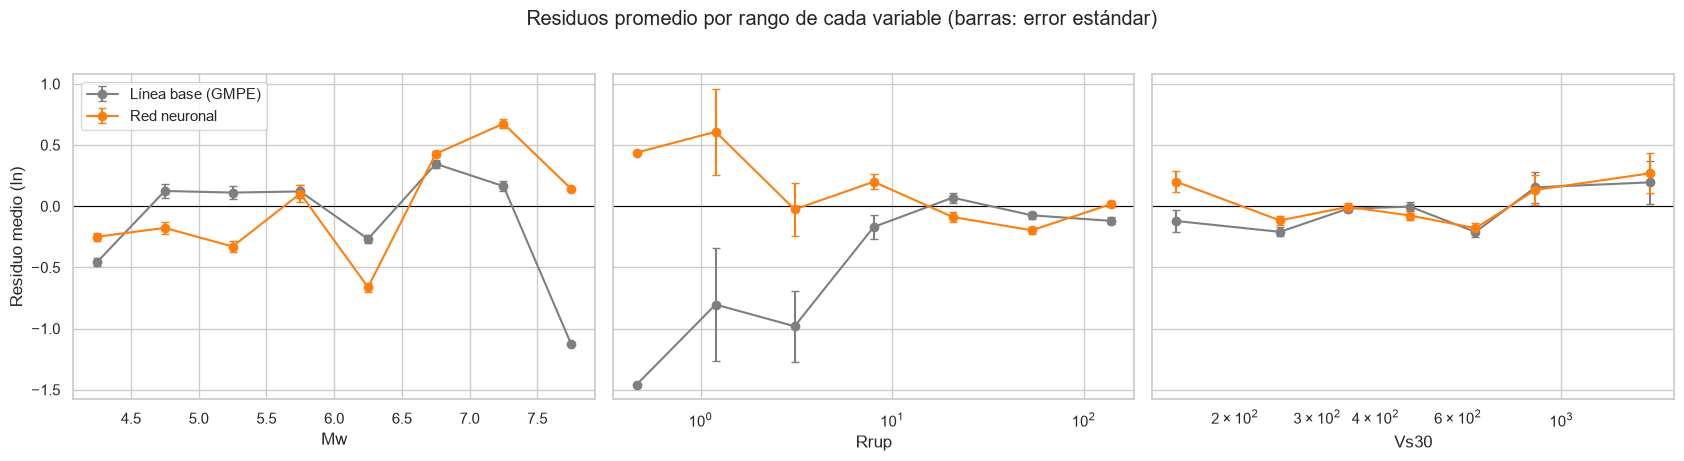

In [9]:
mejor = tabla.drop("Línea base (GMPE)")["RMSE"].idxmin()
print(f"Modelo con menor RMSE: {mejor}")

variables = [("Mw", np.arange(4.0, 8.01, 0.5)),
             (config.DISTANCIA, np.logspace(-1, np.log10(200), 9)),
             ("Vs30", np.array([100, 200, 300, 400, 550, 760, 1000, 2100]))]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for ax, (var, bordes) in zip(axes, variables):
    for nombre in ["Línea base (GMPE)", mejor]:
        r = residuos(entrenados[nombre], test)
        grupos = pd.cut(r[var], bordes)
        stats = r.groupby(grupos, observed=True)["residuo"].agg(["mean", "std", "count"])
        centros = [iv.mid for iv in stats.index]
        ax.errorbar(centros, stats["mean"], yerr=stats["std"] / np.sqrt(stats["count"]),
                    marker="o", capsize=3, color=COLORES[nombre], label=nombre)
    ax.axhline(0, color="black", lw=0.8)
    if var != "Mw":
        ax.set_xscale("log")
    ax.set_xlabel(var)
axes[0].set_ylabel("Residuo medio (ln)")
axes[0].legend()
fig.suptitle("Residuos promedio por rango de cada variable (barras: error estándar)", y=1.02)
plt.tight_layout()
plt.savefig("../results/residuos.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Veredicto según el criterio de éxito

Un modelo **cumple** solo si mejora el RMSE de la línea base y además no viola la
monotonía física (se tolera hasta 1 % de tramos por efectos numéricos).

In [10]:
TOLERANCIA = 1.0  # % de tramos

veredicto = tabla[["RMSE", "mejora vs base (%)"]].copy()
veredicto = veredicto.join(fisica)
veredicto = veredicto.join(ic[["¿mejora robusta?"]])

mejora_rmse = veredicto["RMSE"] < base
coherente = ((veredicto["% violaciones en distancia"] <= TOLERANCIA) &
             (veredicto["% violaciones en magnitud"] <= TOLERANCIA))

veredicto["mejora RMSE"] = np.where(mejora_rmse, "Sí", "No")
veredicto["coherente físicamente"] = np.where(coherente, "Sí", "No")
veredicto["CUMPLE el criterio"] = np.where(mejora_rmse & coherente, "SÍ", "no")
veredicto.loc["Línea base (GMPE)", ["mejora RMSE", "¿mejora robusta?", "CUMPLE el criterio"]] = "—"

veredicto.round(3)

,RMSE,mejora vs base (%),% violaciones en distancia,% violaciones en magnitud,¿mejora robusta?,mejora RMSE,coherente físicamente,CUMPLE el criterio
modelo,,,,,,,,
Línea base (GMPE),0.865,0.000,0.000,0.000,—,—,Sí,—
Random Forest,0.821,5.087,15.354,13.750,No,Sí,No,no
XGBoost,0.813,6.020,0.000,16.250,No,Sí,No,no
XGBoost monótono,0.818,5.503,0.000,0.000,No,Sí,Sí,SÍ
Red neuronal,0.813,6.046,0.000,12.396,No,Sí,No,no


In [11]:
# Guardar resultados para el informe y la presentación
config.DIR_RESULTADOS.mkdir(exist_ok=True)
veredicto.round(4).to_csv(config.DIR_RESULTADOS / "resultados_prueba.csv", encoding="utf-8-sig")
ic.round(4).to_csv(config.DIR_RESULTADOS / "bootstrap_mejoras.csv", encoding="utf-8-sig")
print("Guardado: results/resultados_prueba.csv y results/bootstrap_mejoras.csv")

Guardado: results/resultados_prueba.csv y results/bootstrap_mejoras.csv


## 7. Lectura para el informe

Preguntas a responder por escrito en la sección de resultados del informe IEEE:

1. **¿Algún modelo cumple el criterio de éxito?** Ver la última columna de la tabla de la
   sección 6.
2. **¿La mejora sobre la línea base es robusta?** Ver el bootstrap de la sección 3. Si el
   intervalo incluye el cero, se debe decir con claridad que la mejora no es concluyente.
3. **¿Qué modelos violan la física y dónde?** Ver la sección 4. Relacionarlo con el problema
   de la "caja negra" planteado en el T1.
4. **¿Qué capturan los modelos de ML que la línea base no?** Ver los residuos de la
   sección 5, en especial a distancias cortas (saturación) y en suelos blandos
   (Vs30 bajo).
5. **¿Qué pasa en la región crítica?** Reportar las cifras con la advertencia del tamaño
   de la muestra.